# Survival analysis based on gene expression levels (Cox and logrank)

In [ ]:
conda install -c conda-forge lifelines

In [73]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

## Define the dataset and groups of interest to plot

Indicate the file name manually

In [74]:
significant = pd.read_csv('basal-like_significant_genes.csv', index_col = 0)

In [75]:
gene_list = [i for i in significant.index]

In [76]:
gene_list

['KDM4B',
 'JMJD8',
 'HR',
 'EZH2',
 'GSTCD',
 'SETD7',
 'SMYD2',
 'SUV39H2',
 'ANTKMT',
 'CBX4',
 'CHD1',
 'CBX2',
 'CHD6',
 'CHD7',
 'CDYL2',
 'MSL3',
 'SCML2',
 'LBR',
 'PHF19',
 'KAT6B',
 'JADE2',
 'TCF20',
 'TCF19',
 'FGD1',
 'FGD3',
 'MYRIP',
 'SYTL5',
 'SYTL4',
 'PLEKHF1',
 'FYCO1',
 'MLPH',
 'PLEKHF2',
 'SYTL2',
 'DNMT3B',
 'RPH3AL',
 'PSIP1',
 'HDGF',
 'PEX7',
 'WDR4',
 'TLE1',
 'TLE3',
 'TLE4',
 'CDC20',
 'STRN3',
 'BOP1',
 'WDR43',
 'ELP2',
 'DCAF5',
 'WDR90',
 'CORO6',
 'DMXL1',
 'KCTD3',
 'ORC1']

In [77]:
gene_name = "MLPH"

In [78]:
dataset_name = 'TCGA-BRCA'
survival_type = 'os'

## Import a project

In [81]:
pickle_file = './LysOnc.pickle'
with open(pickle_file, 'rb') as f:
    project = pickle.load(f)

## Load data

In [82]:
data_file = project['data_dir'] + project['datasets'][dataset_name]['data']
data = pd.read_csv(data_file, sep=';', index_col = 0)
if 'id_gene' in data.columns:
    data.drop(columns=['id_gene', 'gene_symbol'], inplace=True)
data.head()

,TCGA-3C-AAAU-01A,TCGA-3C-AALI-01A,TCGA-3C-AALJ-01A,TCGA-3C-AALK-01A,TCGA-4H-AAAK-01A,TCGA-5L-AAT0-01A,TCGA-5L-AAT1-01A,TCGA-5T-A9QA-01A,TCGA-A1-A0SB-01A,TCGA-A1-A0SD-01A,...,TCGA-UL-AAZ6-01A,TCGA-UU-A93S-01A,TCGA-V7-A7HQ-01A,TCGA-W8-A86G-01A,TCGA-WT-AB41-01A,TCGA-WT-AB44-01A,TCGA-XX-A899-01A,TCGA-XX-A89A-01A,TCGA-Z7-A8R5-01A,TCGA-Z7-A8R6-01A
gene_symbol,,,,,,,,,,,,,,,,,,,,,
AAMP,5.286755,5.780848,5.397889,5.555282,5.882320,6.038434,5.833199,6.100734,5.308415,5.481703,...,6.160888,5.465612,6.241497,5.672821,6.185040,5.111290,5.368335,5.565539,5.738852,5.656682
AIRE,0.049352,0.017067,0.000000,0.023894,0.013212,0.054640,0.000000,0.000000,0.000000,0.000000,...,0.005472,0.000000,0.016068,0.052138,0.189413,0.031677,0.043064,0.027012,0.000000,0.005759
RERE,4.652532,3.795819,3.328334,3.559088,3.594298,3.515132,3.492597,3.658634,3.957506,3.611420,...,3.094523,2.283240,2.530121,3.895370,2.797490,2.363536,3.922065,3.455676,3.087887,3.644652
ATR,1.760902,1.325617,1.086512,1.030901,1.192573,1.050815,1.140451,1.094439,1.757663,1.452068,...,0.830418,1.176897,0.363339,1.224287,0.626205,1.081067,1.456070,1.092816,0.888227,0.860129
ATRX,3.211713,1.675274,1.855392,2.134944,2.287295,1.965729,1.619319,1.186120,3.047730,2.918348,...,1.365804,1.482848,1.372729,2.016532,1.024391,0.861241,2.491032,2.299889,1.496820,1.692561


## Load clinical annotations

In [83]:
clinical_file = project['data_dir'] + project['datasets'][dataset_name]['clinical']
clinical = pd.read_csv(clinical_file, sep=';', index_col=0)
clinical

,main_gse_number,id_platform,organism,sample_title,sample_source,sex,ethnic_group,age_min,age_max,id_tissue_stage,...,her2_and_cent17_cells_count_clin_shared_days_to_death,her2_cent17_ratio_clin_shared_radiation_therapy,her2_copy_number_brca_shared_her2_neu_and_centromere_17_copy_number_analysis_input_total_number_count,her2_fish_method_brca_shared_metastatic_breast_carcinoma_erbb2_immunohistochemistry_level_result,her2_fish_status_nte_additional_surgery_metastatic_procedure,her2_ihc_percent_positive_brca_shared_breast_carcinoma_progesterone_receptor_status,her2_positivity_method_text_clin_shared_person_neoplasm_cancer_status,pr_positivity_ihc_intensity_score_brca_shared_metastatic_breast_carcinoma_estrogen_receptor_detection_method_text,pr_status_ihc_percent_positive_follow_up_v1_5_follow_up,source_sample_id
id_sample,,,,,,,,,,,,,,,,,,,,,
TCGA-3C-AAAU-01A,TCGA-BRCA,multi,Homo sapiens,197b76a1-a09a-4659-83aa-2c14fd1023a9,Primary Tumor,F,not hispanic or latino,55.37,55.37,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-3C-AALI-01A,TCGA-BRCA,multi,Homo sapiens,0050d7c9-ece9-4b6c-8023-1ff2efcb3c9c,Primary Tumor,F,not hispanic or latino,50.79,50.79,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-3C-AALJ-01A,TCGA-BRCA,multi,Homo sapiens,e355913a-6e4c-4d63-8a53-8be4c5b003b8,Primary Tumor,F,not hispanic or latino,62.60,62.60,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-3C-AALK-01A,TCGA-BRCA,multi,Homo sapiens,2a532346-0008-4af8-99bc-d709585da1d6,Primary Tumor,F,not hispanic or latino,52.26,52.26,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-4H-AAAK-01A,TCGA-BRCA,multi,Homo sapiens,685b5df4-0620-40e2-aa09-0dd736bb5e2b,Primary Tumor,F,not hispanic or latino,50.33,50.33,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-WT-AB44-01A,TCGA-BRCA,multi,Homo sapiens,081947cf-1635-4a57-9903-0c405ead6d84,Primary Tumor,F,not hispanic or latino,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-XX-A899-01A,TCGA-BRCA,multi,Homo sapiens,43623706-5604-4f3d-8746-9bfa0b92c0a9,Primary Tumor,F,not hispanic or latino,46.64,46.64,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-XX-A89A-01A,TCGA-BRCA,multi,Homo sapiens,1422b157-eec7-460e-96c8-9121847d283b,Primary Tumor,F,not hispanic or latino,68.49,68.49,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Extract the data corresponding to genes and groups

In [84]:
cox_data = pd.DataFrame(index = data.columns)
cox_data[gene_name] = data.loc[gene_name, cox_data.index]
cox_data['time'] = clinical.loc[cox_data.index, survival_type + '_months']
cox_data['event'] = clinical.loc[cox_data.index, survival_type + '_censor']
cox_data.index.name = 'id_sample'
cox_data.dropna(inplace=True)
cox_data.head()

,MLPH,time,event
id_sample,,,
TCGA-3C-AAAU-01A,5.645875,134.90,0.0
TCGA-3C-AALI-01A,7.156129,133.50,0.0
TCGA-3C-AALJ-01A,5.308015,49.13,0.0
TCGA-3C-AALK-01A,6.306563,48.27,0.0
TCGA-4H-AAAK-01A,5.563213,11.60,0.0


## Cox proportional hazard model 

In [85]:
cph = CoxPHFitter()
cph.fit(cox_data, duration_col='time', event_col='event', show_progress=False)
cox_pvalue = cph.summary.p[gene_name]
cox_hr = cph.summary['exp(coef)'][gene_name]
cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
MLPH,-0.067087,0.935114,0.036384,-0.138397,0.004224,0.870753,1.004233,0.0,-1.84387,0.065202,3.938937


## Create groups corresponding to up and down-regulated gene

In [86]:
cox_data['group'] = 0
threshold = cox_data[gene_name].median() 
cox_data.loc[cox_data[gene_name]>threshold, 'group'] = 1
cox_data.drop(columns=[gene_name], inplace=True)
cox_data.head()

,time,event,group
id_sample,,,
TCGA-3C-AAAU-01A,134.90,0.0,1
TCGA-3C-AALI-01A,133.50,0.0,1
TCGA-3C-AALJ-01A,49.13,0.0,0
TCGA-3C-AALK-01A,48.27,0.0,1
TCGA-4H-AAAK-01A,11.60,0.0,1


## Logrank test

In [87]:
cph.fit(cox_data, duration_col='time', event_col='event', show_progress=False)
cox_bin_pvalue = cph.summary.p['group']
cox_bin_hr = cph.summary['exp(coef)']['group']
logrank = multivariate_logrank_test(cox_data['time'], cox_data['group'], cox_data['event'])
logrank_pvalue = logrank.p_value
print('Cox p-value for binarized groups = {:.3f}, logrank p-value = {:.3f}'.format(cox_bin_pvalue, logrank_pvalue))

Cox p-value for binarized groups = 0.000, logrank p-value = 0.000


In [88]:
cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
group,-0.594582,0.551793,0.151754,-0.892014,-0.29715,0.409829,0.742933,0.0,-3.918065,0.000089,13.451584


## Plot Kaplan-Meier survival curves

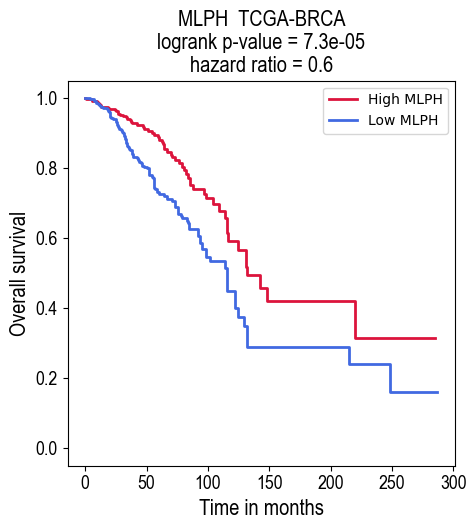

In [89]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
group_labels = {0: 'Low ' + gene_name, 1: 'High ' + gene_name}
group_colors = {0: 'royalblue', 1: 'crimson'}
font = {'fontname':'Arial', 'stretch' : 'condensed', 'fontsize': 16}

kmf = KaplanMeierFitter()
for g in cox_data['group'].unique():
    group_data = cox_data[cox_data['group']==g]
    kmf.fit(group_data['time'], group_data['event'], label=group_labels[g])
    kmf.plot(ax=ax, ci_show=False, show_censors=False, color=group_colors[g], linewidth=2)

title = gene_name + '  ' + dataset_name + '\nlogrank p-value = {:.1e}'.format(logrank_pvalue) + '\nhazard ratio = {:.1f}'.format(cox_bin_hr) 
ax.set_title(title, **font)
ax.set_ylim([-0.05, 1.05])

max_survival_time = round(cox_data['time'].max(), 0)
step_time = 50
ax.set_xlim([0.0 - 0.05*max_survival_time, max_survival_time + 0.05*max_survival_time])

xticks = [int(xi) for xi in np.arange(0, max_survival_time + step_time, step_time)]
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, **font)
        
yticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
ax.set_yticks(yticks)
ax.set_yticklabels(yticks, **font)

survival_name = {'os': 'Overall survival', 'dfs': 'Disease-free survial'}
ax.set_ylabel(survival_name[survival_type], **font)
ax.set_xlabel('Time in months', **font)
ax.tick_params(axis='both', labelsize=font['fontsize']-2)